# Time Series_ London Air Quality Data_pm25 level

In [ ]:
pip install prophet

In [23]:
!pip uninstall -y prophet fbprophet
!pip install -qqq prophet

In [1]:
# Importing libraries

import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from statsmodels.tsa.seasonal import seasonal_decompose, DecomposeResult
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error

from typing import Any

In [2]:
# Importing  data 

air_quality_data = pd.read_csv("london_air_quality_2010_2023_top5_sites.csv")

In [3]:
# Selecting the desired data

kensington_pm25 = air_quality_data[
    air_quality_data["SiteName"] == "Kensington and Chelsea - North Ken"
][["datetime", "pm25_level"]]
kensington_pm25.head()

,datetime,pm25_level
237905,2010-01-01 00:00:00,NaN
237906,2010-01-01 01:00:00,NaN
237907,2010-01-01 02:00:00,NaN
237908,2010-01-01 03:00:00,NaN
237909,2010-01-01 04:00:00,NaN


In [4]:
# Updating Date datatype , setting it as index & sorting it chronologically

kensington_pm25["datetime"] = pd.to_datetime(kensington_pm25["datetime"])

kensington_pm25: pd.DataFrame = kensington_pm25.set_index("datetime")
# Ensure the data is sorted chronologically
kensington_pm25: pd.DataFrame = kensington_pm25.sort_index()

kensington_pm25.head()

,pm25_level
datetime,
2010-01-01 00:00:00,NaN
2010-01-01 01:00:00,NaN
2010-01-01 02:00:00,NaN
2010-01-01 03:00:00,NaN
2010-01-01 04:00:00,NaN


In [5]:
# Imputing missing values
k_pm25_clean = kensington_pm25.interpolate(method="time")

In [6]:
#  Resample to Daily averages 
k_pm25_daily = (
    k_pm25_clean
    .resample("D")
    .mean().round(2)
    .reset_index()
)
k_pm25_daily.head()

,datetime,pm25_level
0,2010-01-01,NaN
1,2010-01-02,NaN
2,2010-01-03,NaN
3,2010-01-04,NaN
4,2010-01-05,22.91


## Preparing dataset

In [7]:

# Rename the columns to 'ds' and 'y' as required by Prophet
k_pm25: pd.DataFrame = k_pm25_daily.rename(columns={'datetime': 'ds', 'pm25_level': 'y'})

# Ensure 'ds' is datetime type and set as index temporarily for time-interpolation
k_pm25["ds"] = pd.to_datetime(k_pm25["ds"])
k_pm25 = k_pm25.set_index("ds").sort_index()

# Perform time-based interpolation to handle missing gaps
k_pm25["y"] = k_pm25["y"].bfill() .interpolate(method='linear')  # Interpolates any isolated internal NaNs


# Reset index so 'ds' returns as a regular column (as required by Prophet)
k_pm25 = k_pm25.reset_index()


# Check the first few rows after renaming
k_pm25.head()

,ds,y
0,2010-01-01,22.91
1,2010-01-02,22.91
2,2010-01-03,22.91
3,2010-01-04,22.91
4,2010-01-05,22.91


In [8]:
k_pm25.isna().sum()

ds    0
y     0
dtype: int64

## Train Test Split

In [9]:
k_pm25: pd.DataFrame

# Define the split point - for example, use 90% of data for training and 10% for testing
split_index: int = int(len(k_pm25) * 0.9)
train_df: pd.DataFrame = k_pm25.iloc[:split_index].copy()
test_df: pd.DataFrame = k_pm25.iloc[split_index:].copy()

print(f"Training period: {train_df['ds'].min().date()} to {train_df['ds'].max().date()}")
print(f"Testing period: {test_df['ds'].min().date()} to {test_df['ds'].max().date()}")
print(f"Training points: {len(train_df)}, Testing points: {len(test_df)}")

Training period: 2010-01-01 to 2022-08-05
Testing period: 2022-08-06 to 2023-12-30
Training points: 4600, Testing points: 512


## Applying Prophet Model

### Without Holiday

In [10]:
train_df: pd.DataFrame

# Set up the Prophet model (using default settings for now)
model: Prophet = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=True,
    changepoint_prior_scale=0.05,# controls trend flexibility
    seasonality_mode= 'additive',
)

# Fit the model to the training data
model.fit(train_df)

10:23:47 - cmdstanpy - INFO - Chain [1] start processing
10:23:47 - cmdstanpy - INFO - Chain [1] done processing


### With Holiday

In [11]:
# Initialise Prophet with UK holidays

from prophet.make_holidays import make_holidays_df
  
## Fetch official UK / England Bank Holidays
year_list: list[int] = list(range(2010, 2024))
uk_holidays = make_holidays_df(year_list=year_list, country="UK", province="ENG")

bonfire_nights = pd.DataFrame({
  'holiday': 'bonfire_night',
  'ds': pd.to_datetime(['2010-11-05', '2011-11-05','2012-11-05', '2013-11-05','2014-11-05', '2015-11-05','2016-11-05', 
                        '2017-11-05','2018-11-05', '2019-11-05','2020-11-05', '2021-11-05', '2022-11-05', '2023-11-05' ]),
  'lower_window': 0,
  'upper_window': 1, # Captures smoke lingering overnight
})
#  Combine both holiday sources into a single DataFrame
lon_holidays = (
    pd.concat([uk_holidays, bonfire_nights], ignore_index=True)
    .sort_values("ds")
    .reset_index(drop=True)
)
## Fit Prophet with the holidays selected
model_uk: Prophet = Prophet(
                        daily_seasonality=True,
                        weekly_seasonality=True,
                        yearly_seasonality=True,
                        changepoint_prior_scale=0.05,   # controls trend flexibility
                        seasonality_mode= 'additive',
                        holidays=lon_holidays)
model_uk.fit(k_pm25)  
 
print(model_uk.train_holiday_names)

10:23:50 - cmdstanpy - INFO - Chain [1] start processing
10:23:50 - cmdstanpy - INFO - Chain [1] done processing


0                          New Year's Day
1                             Good Friday
2                           Easter Monday
3                                 May Day
4                     Spring Bank Holiday
5                Late Summer Bank Holiday
6                           bonfire_night
7                           Christmas Day
8                              Boxing Day
9                Christmas Day (observed)
10                  Boxing Day (observed)
11              New Year's Day (observed)
12       Wedding of William and Catherine
13        Diamond Jubilee of Elizabeth II
14       Platinum Jubilee of Elizabeth II
15    State Funeral of Queen Elizabeth II
16              Coronation of Charles III
dtype: object


In [12]:
# uk_holidays.sort_values("ds")

## Forecasting Future Values

In [13]:
test_df: pd.DataFrame

# Calculate the number of days between the first and last dates of the test set
days_in_test_set_range: int = (test_df['ds'].max() - train_df['ds'].max()).days

print(f"Number of days in the test set range: {days_in_test_set_range}")

Number of days in the test set range: 512


### Without Holiday

In [14]:
# Create a dataframe that extends into the future (covering the test period)
future: pd.DataFrame = model.make_future_dataframe(periods=len(test_df), freq="D")

# Use the model to make predictions for those future dates
forecast: pd.DataFrame = model.predict(future)

# Look at the last few predictions
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
5107,2023-12-26,7.319558,-3.082215,18.569654
5108,2023-12-27,7.723420,-3.511331,18.878773
5109,2023-12-28,7.691695,-2.185496,18.109129
5110,2023-12-29,7.657993,-2.729929,18.342129
5111,2023-12-30,7.524701,-3.437791,18.565665


### With Holiday

In [15]:
# Create the future dataframe using the exact test set dates
future_uk: pd.DataFrame = test_df[['ds']].copy()

# Pass the explicit date range of your entire test set (or combined train + test)
future_uk: pd.DataFrame = pd.concat([train_df[['ds']], test_df[['ds']]], ignore_index=True)


# Generate predictions strictly for the test dates
forecast_uk: pd.DataFrame = model_uk.predict(future_uk)

# Verify dates end in 2023
forecast_uk[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
5107,2023-12-26,6.247454,-4.660073,16.191477
5108,2023-12-27,6.585862,-4.129075,16.634940
5109,2023-12-28,6.567197,-3.502305,16.488785
5110,2023-12-29,6.504466,-3.950849,16.563498
5111,2023-12-30,6.478038,-4.045834,16.277423


## Visualising the Forecast

### Without Holiday

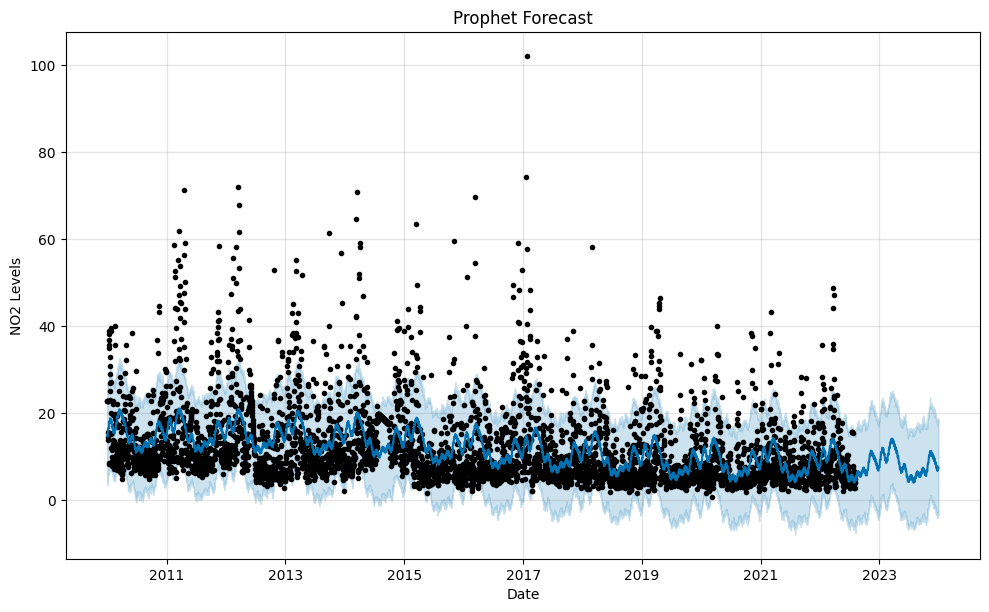

In [16]:
fig1a: Any = model.plot(forecast)
plt.title('Prophet Forecast')
plt.xlabel('Date')
plt.ylabel('NO2 Levels')
plt.show()

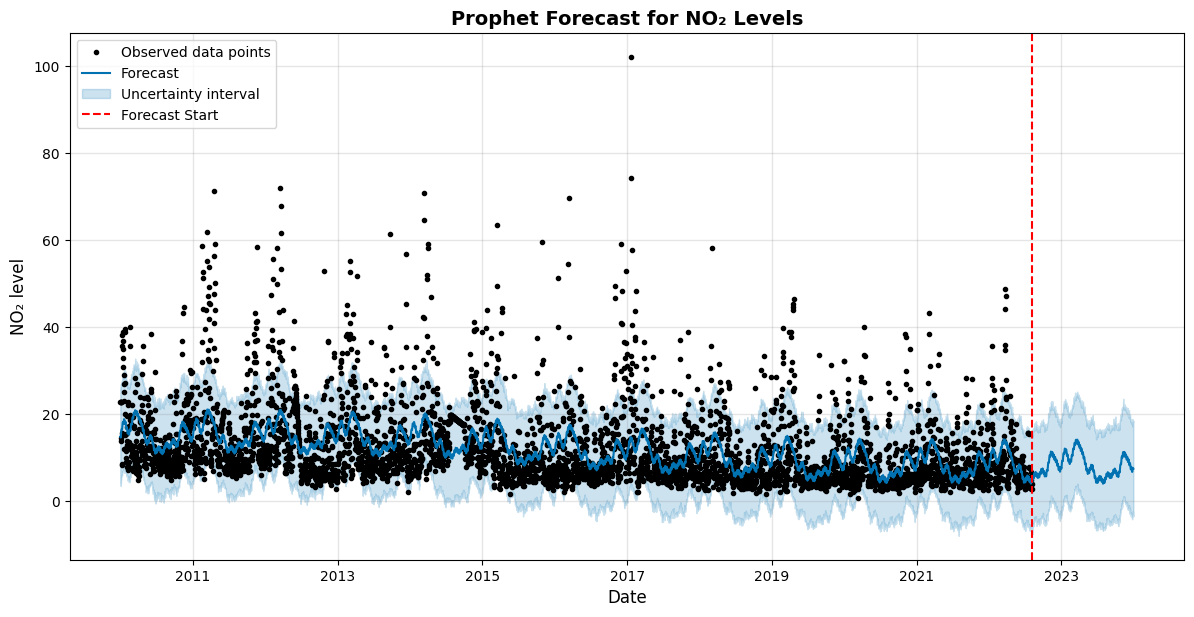

In [17]:
# Refined Visualization
import matplotlib.pyplot as plt

# 1. Create base Prophet forecast plot
fig1 = model.plot(forecast, figsize=(12, 6))
ax = fig1.gca()

# 2. Add titles and axis labels
ax.set_title("Prophet Forecast for NO₂ Levels", fontsize=14, fontweight="bold")
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("NO₂ level", fontsize=12)

# 3. Add a vertical line for Train/Test split cutoff
train_end_date = train_df["ds"].max()
ax.axvline(
    x=train_end_date,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="Forecast Start",
)

ax.legend(loc="upper left")
plt.show()

### With Holiday

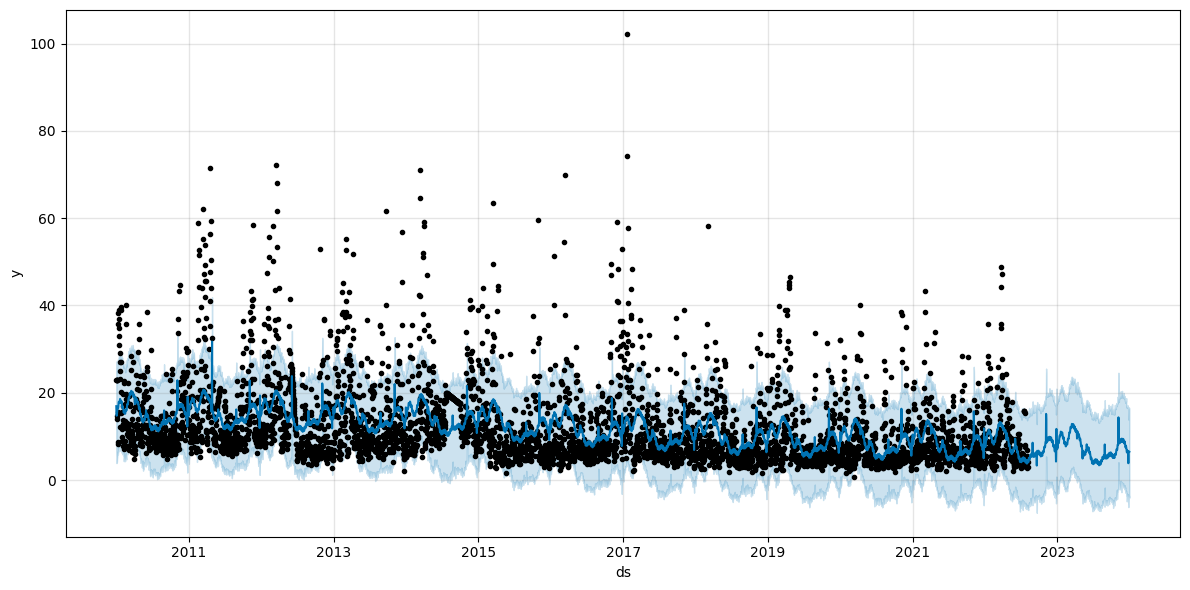

In [18]:
# Refined Visualization
import matplotlib.pyplot as plt

# 1. Create base Prophet forecast plot
fig1b = model.plot(forecast_uk, figsize=(12, 6))
ax = fig1.gca()

# 2. Add titles and axis labels
ax.set_title("Prophet Forecast for NO₂ Levels", fontsize=14, fontweight="bold")
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("NO₂ level", fontsize=12)

# 3. Add a vertical line for Train/Test split cutoff
train_end_date = train_df["ds"].max()
ax.axvline(
    x=train_end_date,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="Forecast Start",
)

ax.legend(loc="upper left")
plt.show()

## Trend and Seasonality Components

### Without Holiday

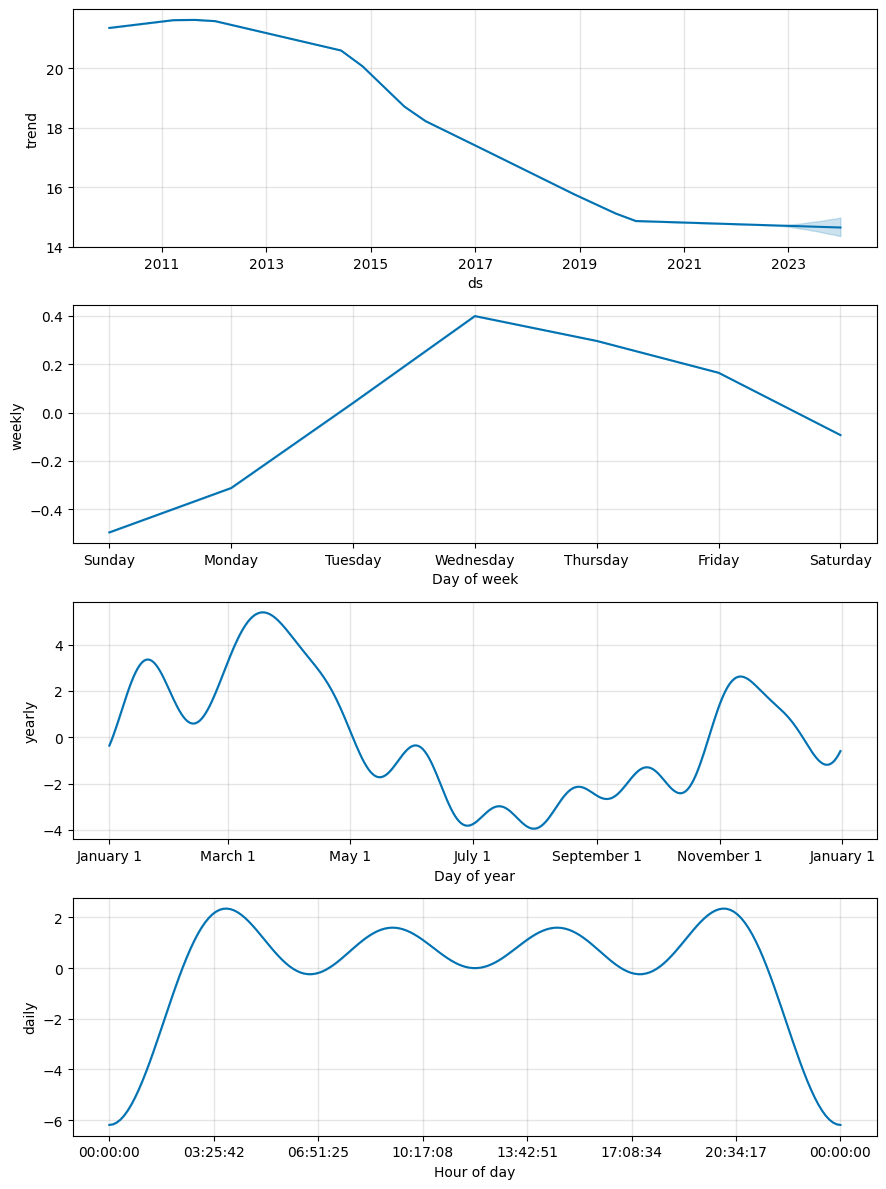

In [19]:
# Plot the trend and seasonality components
fig2a: Any = model.plot_components(forecast)
plt.show()

### With Holiday

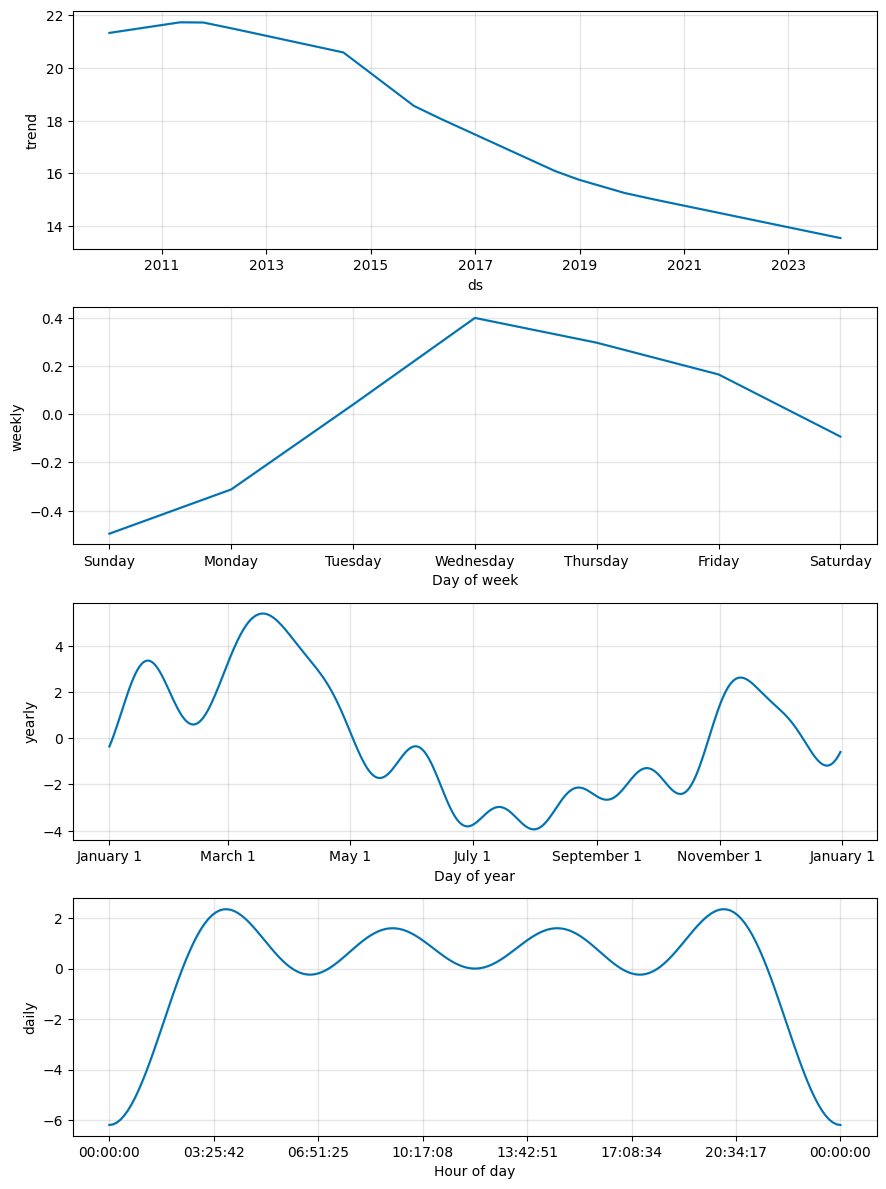

In [20]:
# Plot the trend and seasonality components
fig2b: Any = model.plot_components(forecast_uk)
plt.show()

## Evaluating Forecast Performance

### Without Holiday

In [21]:
import numpy as np
import pandas as pd

# 1. Merge forecast and actuals on 'ds' to guarantee exact row alignment
eval_df: pd.DataFrame = pd.merge(
    test_df[["ds", "y"]],
    forecast[["ds", "yhat"]],
    on="ds",
    how="inner",
).dropna()

# 2. Extract arrays
y_true: np.ndarray = eval_df["y"].values
y_pred: np.ndarray = eval_df["yhat"].values

# 3. Calculate MAE & RMSE
mae: float = np.mean(np.abs(y_true - y_pred))
rmse: float = np.sqrt(np.mean((y_true - y_pred) ** 2))


# 4. Calculate MAPE safely (avoiding zero division)
eps = 1e-8  # Small epsilon to prevent division by zero
mape: float = np.mean(np.abs((y_true - y_pred) / (y_true + eps))) * 100


print(f"Evaluation Metrics:")
print(f"\t Mean Absolute Error (MAE): {mae:.2f}")
print(f"\t Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"\t Mean Absolute Percentage Error (MAPE): {mape:.2f}%")


Evaluation Metrics:
	 Mean Absolute Error (MAE): 3.42
	 Root Mean Squared Error (RMSE): 4.43
	 Mean Absolute Percentage Error (MAPE): 59.62%


### With Holiday

In [22]:
# 1. Merge forecast and actuals on 'ds' to guarantee exact row alignment
eval_df_uk: pd.DataFrame = pd.merge(
    test_df[["ds", "y"]],
    forecast_uk[["ds", "yhat"]],
    on="ds",
    how="inner",
).dropna()

# 2. Extract arrays
y_true: np.ndarray = eval_df_uk["y"].values
y_pred: np.ndarray = eval_df_uk["yhat"].values

# 3. Calculate MAE & RMSE
mae: float = np.mean(np.abs(y_true - y_pred))
rmse: float = np.sqrt(np.mean((y_true - y_pred) ** 2))


# 4. Calculate MAPE safely (avoiding zero division)
eps = 1e-8  # Small epsilon to prevent division by zero
mape: float = np.mean(np.abs((y_true - y_pred) / (y_true + eps))) * 100


print(f"Evaluation Metrics with Holiday:")
print(f"\t Mean Absolute Error (MAE) with holidays: {mae:.2f}")
print(f"\t Root Mean Squared Error (RMSE)with holidays: {rmse:.2f}")
print(f"\t Mean Absolute Percentage Error (MAPE)with holidays: {mape:.2f}%")


Evaluation Metrics with Holiday:
	 Mean Absolute Error (MAE) with holidays: 3.06
	 Root Mean Squared Error (RMSE)with holidays: 4.13
	 Mean Absolute Percentage Error (MAPE)with holidays: 49.03%


## Plotting Actual vs Predicted

### Without Holiday

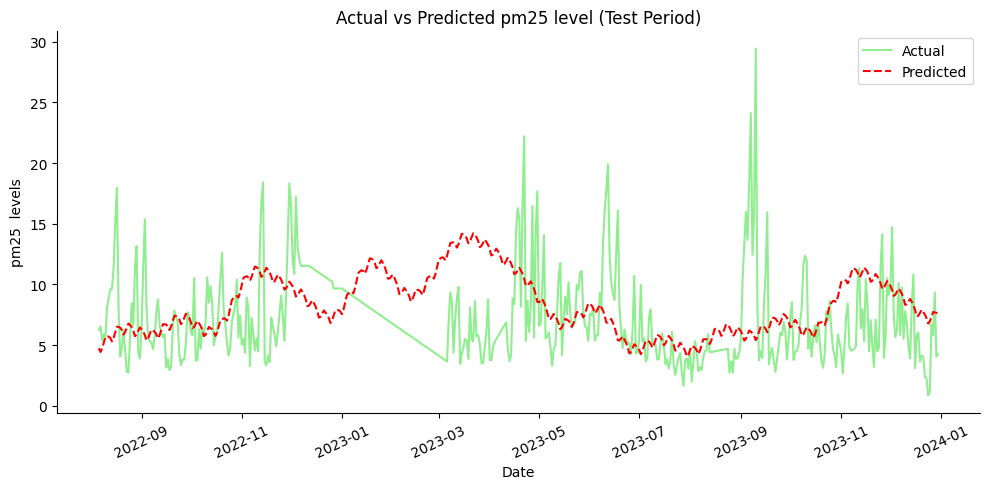

In [23]:
# Create the initial plot- Actual values

g: sns.FacetGrid = sns.relplot(
    kind='line',
    data=test_df,
    x='ds',
    y='y',
    label='Actual',
    aspect=2,
    height=5,
    color='lightgreen'
)

# Add the forecast line
_ = sns.lineplot(
    data=eval_df,
    #data= forecast_test,
    x='ds',
    y='yhat',
    label='Predicted',
    linestyle='--',
    ax=g.ax,
    color='red'
)

# Customise labels and title
g.set_axis_labels("Date", "pm25  levels")
g.set(title="Actual vs Predicted pm25 level (Test Period)")

# Rotate x-axis labels
g.ax.tick_params(axis='x', rotation=25)

# Show the plot
g.figure.tight_layout();

### With Holidays

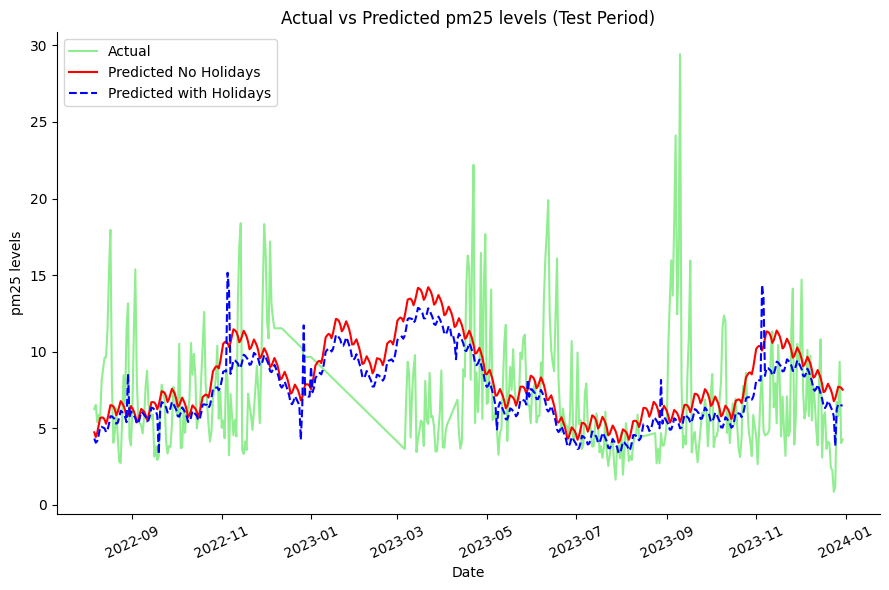

In [24]:

# Create the initial plot-Actual
g: sns.FacetGrid = sns.relplot(
    kind='line',
    data=test_df,
    x='ds',
    y='y',
    label='Actual',
    aspect=1.5,
    height=6,
    color='lightgreen'
)

# Add the forecast line
_ = sns.lineplot(
    data=eval_df,
    x='ds',
    y='yhat',
    label='Predicted No Holidays',
    ax=g.ax,
    color='red'
)

# Add the forecast line
_ = sns.lineplot(
    data=eval_df_uk,
    x='ds',
    y='yhat',
    label='Predicted with Holidays',
    linestyle='--',
    ax=g.ax,
    color='blue'
)

# Customise labels and title
g.set_axis_labels("Date", "pm25 levels")
g.set(title="Actual vs Predicted pm25 levels (Test Period)")

# Rotate x-axis labels
g.ax.tick_params(axis='x', rotation=25)

# Show the plot
g.figure.tight_layout();